In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('mymoviedb.csv' , lineterminator = '\n')

In [3]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url,\r
0,15-12-2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...,\r
1,01-03-2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...,\r
2,25-02-2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...,\r
3,24-11-2021,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...,\r
4,22-12-2021,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...,\r


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9837 non-null   object 
 1   Title              9828 non-null   object 
 2   Overview           9828 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   object 
 5   Vote_Average       9827 non-null   object 
 6   Original_Language  9827 non-null   object 
 7   Genre              9826 non-null   object 
 8   Poster_Url         9826 non-null   object 
                9837 non-null   object 
dtypes: float64(1), object(9)
memory usage: 768.6+ KB


In [5]:
df.describe()

,Popularity
count,9827.000000
mean,40.320570
std,108.874308
min,7.100000
25%,16.127500
50%,21.191000
75%,35.174500
max,5083.954000


In this we dont have any use of overview , original_language and poster_url columns so we drop it

In [6]:
df = df.drop(columns = ['Original_Language', 'Poster_Url', 'Overview'])

In [7]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,\r
0,15-12-2021,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction",\r
1,01-03-2022,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller",\r
2,25-02-2022,No Exit,2618.087,122,6.3,Thriller,\r
3,24-11-2021,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy",\r
4,22-12-2021,The King's Man,1895.511,1793,7,"Action, Adventure, Thriller, War",\r


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Release_Date  9837 non-null   object 
 1   Title         9828 non-null   object 
 2   Popularity    9827 non-null   float64
 3   Vote_Count    9827 non-null   object 
 4   Vote_Average  9827 non-null   object 
 5   Genre         9826 non-null   object 
           9837 non-null   object 
dtypes: float64(1), object(6)
memory usage: 538.1+ KB


looking at above we saw that release_date , vote_count and vote_average are of object type so we have to convert their datatype

In [9]:
df['Vote_Count'] = pd.to_numeric(df['Vote_Count'] , errors = 'coerce')
df['Vote_Average'] = pd.to_numeric(df['Vote_Average'] , errors = 'coerce')

In [10]:
df['Release_Date'] = pd.to_datetime(df['Release_Date'] , errors = 'coerce')

C:\Users\Anchal\AppData\Local\Temp\ipykernel_6796\71534219.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Release_Date'] = pd.to_datetime(df['Release_Date'] , errors = 'coerce')


In [11]:
df['Release_Date'] = df['Release_Date'].dt.year

In [12]:
df['Release_Date'] = df['Release_Date'].astype('Int64')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Release_Date  9827 non-null   Int64  
 1   Title         9828 non-null   object 
 2   Popularity    9827 non-null   float64
 3   Vote_Count    9826 non-null   float64
 4   Vote_Average  9826 non-null   float64
 5   Genre         9826 non-null   object 
           9837 non-null   object 
dtypes: Int64(1), float64(3), object(3)
memory usage: 547.7+ KB


In [14]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,\r
0,2021,Spider-Man: No Way Home,5083.954,8940.0,8.3,"Action, Adventure, Science Fiction",\r
1,2022,The Batman,3827.658,1151.0,8.1,"Crime, Mystery, Thriller",\r
2,2022,No Exit,2618.087,122.0,6.3,Thriller,\r
3,2021,Encanto,2402.201,5076.0,7.7,"Animation, Comedy, Family, Fantasy",\r
4,2021,The King's Man,1895.511,1793.0,7.0,"Action, Adventure, Thriller, War",\r


In [15]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
9832    False
9833    False
9834    False
9835    False
9836    False
Length: 9837, dtype: bool

Categorizing Vote_Average Column : 
we would cut the vote_average values and make 4 categories : popular , average , below_average , not_popular to describe it more using categorize_col() function provided above

In [16]:
def categorize_col(df, col, labels):
    edges = [
        df[col].describe()['min'],
        df[col].describe()['25%'],
        df[col].describe()['50%'],
        df[col].describe()['75%'],
        df[col].describe()['max']
    ]
    df[col] = pd.cut(df[col], edges, labels=labels, duplicates='drop')
    return df

In [17]:
labels = ['not_popular','below_avg','average','popular']

categorize_col(df,'Vote_Average',labels)

df['Vote_Average'].unique()

['popular', 'below_avg', 'average', 'not_popular', NaN]
Categories (4, object): ['not_popular' < 'below_avg' < 'average' < 'popular']

In [18]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,\r
0,2021,Spider-Man: No Way Home,5083.954,8940.0,popular,"Action, Adventure, Science Fiction",\r
1,2022,The Batman,3827.658,1151.0,popular,"Crime, Mystery, Thriller",\r
2,2022,No Exit,2618.087,122.0,below_avg,Thriller,\r
3,2021,Encanto,2402.201,5076.0,popular,"Animation, Comedy, Family, Fantasy",\r
4,2021,The King's Man,1895.511,1793.0,average,"Action, Adventure, Thriller, War",\r


In [19]:
df['Vote_Average'].value_counts()

Vote_Average
not_popular    2467
popular        2450
average        2411
below_avg      2398
Name: count, dtype: int64

In [20]:
df.dropna(inplace = True)
df.isna().sum()

Release_Date    0
Title           0
Popularity      0
Vote_Count      0
Vote_Average    0
Genre           0
  \r            0
dtype: int64

we'd split genres into a list and then explode our dataframe to have only one genre per row for each movie

In [22]:
df['Genre'] = df['Genre'].str.split(', ')
df = df.explode('Genre').reset_index(drop = True)
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,\r
0,2021,Spider-Man: No Way Home,5083.954,8940.0,popular,Action,\r
1,2021,Spider-Man: No Way Home,5083.954,8940.0,popular,Adventure,\r
2,2021,Spider-Man: No Way Home,5083.954,8940.0,popular,Science Fiction,\r
3,2022,The Batman,3827.658,1151.0,popular,Crime,\r
4,2022,The Batman,3827.658,1151.0,popular,Mystery,\r


In [23]:
df['Genre'] = df['Genre'].astype('category')
df['Genre'].dtypes

CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=object)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25551 entries, 0 to 25550
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Release_Date  25551 non-null  Int64   
 1   Title         25551 non-null  object  
 2   Popularity    25551 non-null  float64 
 3   Vote_Count    25551 non-null  float64 
 4   Vote_Average  25551 non-null  category
 5   Genre         25551 non-null  category
           25551 non-null  object  
dtypes: Int64(1), category(2), float64(2), object(2)
memory usage: 1.0+ MB


In [25]:
df.nunique()

Release_Date     100
Title           9414
Popularity      8087
Vote_Count      3265
Vote_Average       4
Genre             19
  \r               1
dtype: int64

# Data Visualization

In [26]:
sns.set_style('whitegrid')

What is the most frequent genre of movies released on netflix?

In [27]:
df['Genre'].describe()

count     25551
unique       19
top       Drama
freq       3715
Name: Genre, dtype: object

C:\Users\Anchal\AppData\Local\Temp\ipykernel_6796\4220472131.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(y= 'Genre', data = df, kind = 'count', order = df['Genre'].value_counts().index,


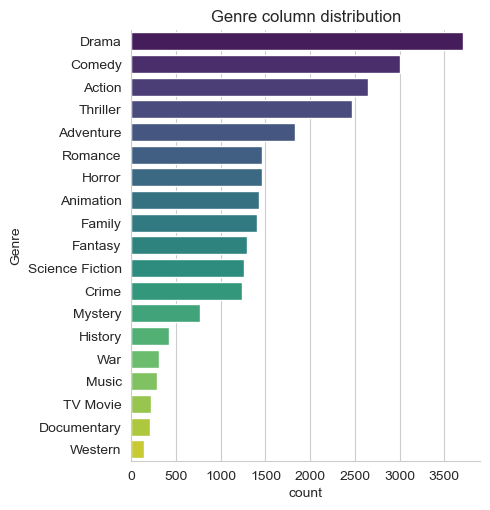

In [30]:
sns.catplot(y= 'Genre', data = df, kind = 'count', order = df['Genre'].value_counts().index,
palette = 'viridis')
plt.title('Genre column distribution')
plt.show()

Which has highest votes in vote avg column?

C:\Users\Anchal\AppData\Local\Temp\ipykernel_6796\1185270023.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(y= 'Vote_Average', data = df, kind = 'count', order = df['Vote_Average'].value_counts().index,


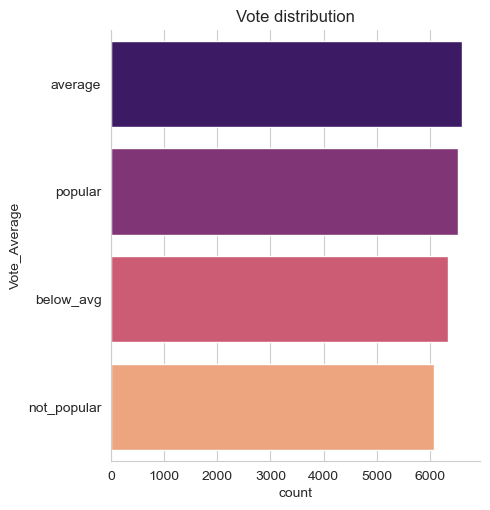

In [36]:
sns.catplot(y= 'Vote_Average', data = df, kind = 'count', order = df['Vote_Average'].value_counts().index,
palette = 'magma')
plt.title('Vote distribution')
plt.show()

Which movie got the highest popularity? Whats its genre?

In [38]:
df[df['Popularity'] == df['Popularity'].max()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,\r
0,2021,Spider-Man: No Way Home,5083.954,8940.0,popular,Action,\r
1,2021,Spider-Man: No Way Home,5083.954,8940.0,popular,Adventure,\r
2,2021,Spider-Man: No Way Home,5083.954,8940.0,popular,Science Fiction,\r


Which movie got the lowest popularity? Whats its genre?

In [39]:
df[df['Popularity'] == df['Popularity'].min()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,\r
25545,2021,The United States vs. Billie Holiday,13.354,152.0,average,Music,\r
25546,2021,The United States vs. Billie Holiday,13.354,152.0,average,Drama,\r
25547,2021,The United States vs. Billie Holiday,13.354,152.0,average,History,\r
25548,1984,Threads,13.354,186.0,popular,War,\r
25549,1984,Threads,13.354,186.0,popular,Drama,\r
25550,1984,Threads,13.354,186.0,popular,Science Fiction,\r


Which year has the most filmmed movie?

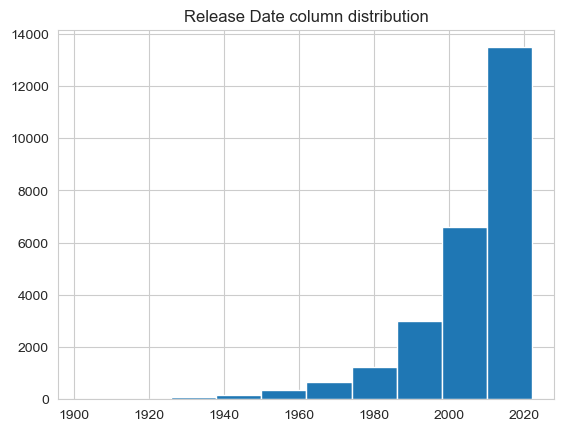

In [40]:
df['Release_Date'].hist()
plt.title('Release Date column distribution')
plt.show()